In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import random
import os
import shutil
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalMaxPooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# train_dir = r"C:\Tomato_Datasets\Dataset\train"
# test_dir = r"C:\Tomato_Datasets\Dataset\test"
# val_dir = r"C:\Tomato_Datasets\Dataset\validation"

# val_ratio = 0.15
# test_ratio = 0.15

# for classname in os.listdir(train_dir):
#     class_path = os.path.join(train_dir, classname)
#     if not os.path.isdir(class_path):
#         continue
    
#     images = os.listdir(class_path)
#     random.shuffle(images)

#     n_total = len(images)
#     n_val = int(n_total * val_ratio)
#     n_test = int(n_total * test_ratio)
    
#     val_images = images[:n_val]
#     test_images = images[n_val:n_val + n_test]

#     os.makedirs(os.path.join(val_dir, classname), exist_ok=True)
#     os.makedirs(os.path.join(test_dir, classname), exist_ok=True)

#     for img in val_images:
#         src = os.path.join(class_path, img)
#         dst = os.path.join(val_dir, classname, img)
#         shutil.move(src, dst)

#     for img in test_images:
#         src = os.path.join(class_path, img)
#         dst = os.path.join(test_dir, classname, img)
#         shutil.move(src, dst)

# print("Progress completed")

In [3]:
train_path = r'/Users/phandangvu/Desktop/DATCOM - AGRICULTURE /Tomato_Datasets/Dataset/train'
val_path = r'/Users/phandangvu/Desktop/DATCOM - AGRICULTURE /Tomato_Datasets/Dataset/validation'
test_path = r'/Users/phandangvu/Desktop/DATCOM - AGRICULTURE /Tomato_Datasets/Dataset/test'

In [4]:
class_encode ={
    0: 'Bacterial spot',
    1: 'Early blight',
    2: 'Healthy',
    3: 'Late blight', 
    4: 'Mold',
    5: 'Mosaic virus',
    6: 'Septoria spot',
    7: 'Target spot',
    8: 'Two spotted spider mites',
    9: 'Yellow virus'
}

In [5]:
# src_dir = train_path
# save_dir = "train_aug"
# images_per_image = 4
#
#
# os.makedirs(save_dir, exist_ok=True)
#
# # Augmentation settings
# datagen = ImageDataGenerator(
#     rotation_range=15,
#     zoom_range=0.2,
#     width_shift_range=0.1,
#     height_shift_range=0.1,
#     horizontal_flip=True,
#     brightness_range=(0.8, 1.2),
#     fill_mode='nearest'
# )
#
# for class_name in os.listdir(src_dir):
#     class_path = os.path.join(src_dir, class_name)
#     if not os.path.isdir(class_path):
#         continue
#
#     save_class_dir = os.path.join(save_dir, class_name)
#     os.makedirs(save_class_dir, exist_ok=True)
#
#     for filename in os.listdir(class_path):
#         img_path = os.path.join(class_path, filename)
#         img = load_img(img_path)
#         x = img_to_array(img)
#         x = np.expand_dims(x, axis=0)
#
#         count = 0
#         for batch in datagen.flow(x, batch_size=1,
#                                   save_to_dir=save_class_dir,
#                                   save_prefix=filename.split('.')[0],
#                                   save_format='jpg'):
#             count += 1
#             if count >= images_per_image:
#                 break


In [6]:
train_gen = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    brightness_range=(0.9, 1.1)
)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    classes=[class_encode[i] for i in class_encode],
    seed=42
)

Found 66225 images belonging to 10 classes.


In [7]:
val_gen = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
)

val_data = val_gen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    classes=[class_encode[i] for i in class_encode],
    seed=42
)

Found 15335 images belonging to 10 classes.


## Stage 1 of training

In [8]:
base_model = MobileNetV2(
    include_top = False,
    weights ='imagenet',
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalMaxPooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 1280)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,079,370 (11.75 MB)

 Trainable params: 821,386 (3.13 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
print("=" * 50)
print("Stage 1: Training Classification Heads")
print("=" * 50)
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    verbose=1
)

Stage 1: Training Classification Heads


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
 320/2070 ━━━━━━━━━━━━━━━━━━━━ 5:51 201ms/step - accuracy: 0.1403 - loss: 3.4818

## Stage 2: Fine-tune with Enhanced Augmentation

In [8]:
base_model.trainable = True
for layer in base_model.layers[:50]:
    layer.trainable = False

train_gen2 = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=(0.85, 1.15)
)

train_data2 = train_gen2.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=True,
    classes=[class_encode[i] for i in class_encode],
    seed=42
)

val_data2 = val_gen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=True,
    classes=[class_encode[i] for i in class_encode],
    seed=42
)

early_stop = EarlyStopping(patience=2, monitor='val_accuracy', restore_best_weights=True)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall']
)
model.summary()

Found 66225 images belonging to 10 classes.
Found 15335 images belonging to 10 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 1280)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,079,370 (11.75 MB)

 Trainable params: 2,995,978 (11.43 MB)

 Non-trainable params: 83,392 (325.75 KB)

In [9]:
history2 = model.fit(
    train_data2,
    validation_data=val_data2,
    epochs=10,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 846s 813ms/step - Precision: 0.7300 - Recall: 0.4601 - accuracy: 0.5668 - loss: 0.3636 - val_Precision: 0.7446 - val_Recall: 0.6871 - val_accuracy: 0.7116 - val_loss: 0.1503
Epoch 2/10
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 835s 807ms/step - Precision: 0.9056 - Recall: 0.8531 - accuracy: 0.8772 - loss: 0.0833 - val_Precision: 0.8915 - val_Recall: 0.8693 - val_accuracy: 0.8775 - val_loss: 0.0662
Epoch 3/10
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 863s 833ms/step - Precision: 0.9409 - Recall: 0.9151 - accuracy: 0.9270 - loss: 0.0521 - val_Precision: 0.9228 - val_Recall: 0.9091 - val_accuracy: 0.9150 - val_loss: 0.0497
Epoch 4/10
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 875s 846ms/step - Precision: 0.9588 - Recall: 0.9437 - accuracy: 0.9499 - loss: 0.0362 - val_Precision: 0.9550 - val_Recall: 0.9463 - val_accuracy: 0.9497 - val_loss: 0.0301
Epoch 5/10
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 859s 829ms/step - Precision: 0.9654 - Recall: 0.9543 - accuracy: 0.9595 - loss: 0.0290 - val_P

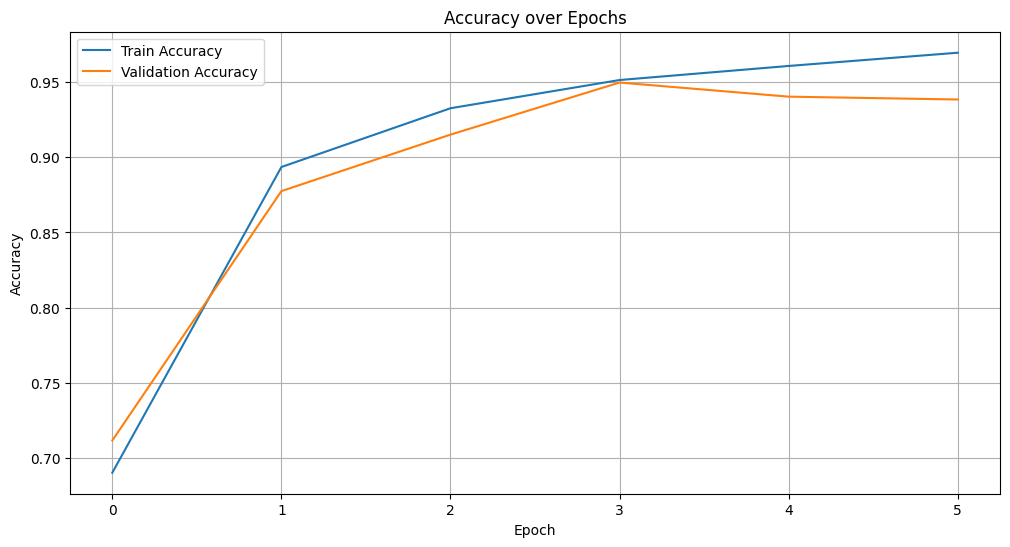

In [10]:
plt.figure(figsize=(12,6))

plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

In [11]:
model.save("Tomato_Leaf_Diseases_Model_0.0.2.keras")